# Customer Churn Prediction — Data Cleaning

This notebook transforms the raw Online Retail II transactional dataset 
into a clean, reliable dataset suitable for churn modeling.

Three types of cleaning are performed:

- **Structural** — removing missing values, duplicates, and invalid records
- **Semantic** — standardizing data types and column names for consistency
- **Behavioral** — classifying transactions into meaningful categories 
  (purchases, returns, voids, administrative) to enable accurate 
  customer-level feature engineering

## Notebook structure

| Section | Content |
|---|---|
| 1. Setup | Libraries and data loading |
| 2. Initial data audit | Structure, missing values, duplicates, invalid records |
| 3. Cleaning strategy | Rationale for each decision before implementation |
| 4. Cleaning implementation | Remove invalids, standardize types, encode cancellations |
| 5. Transaction labeling | Classify transactions into behavioral categories |
| 6. Outlier assessment | Price and quantity distributions by transaction type |
| 7. Data validation | Integrity checks before export |
| 8. Finalization | Compute TotalSum, summarize, save |

## 1. Setup

The raw dataset is the [UCI Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii) 
dataset from a UK-based non-store online retailer. It covers transactions 
between December 2009 and December 2011 and is split across two Excel 
sheets by year.

Both sheets are loaded and concatenated into a single DataFrame before 
any cleaning is applied.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Load both year sheets and concatenate
data_sheets = pd.read_excel(
    '../data/raw/online_retail_II.xlsx',
    sheet_name=None
)

required_sheets = ['Year 2009-2010', 'Year 2010-2011']
missing_sheets  = [s for s in required_sheets if s not in data_sheets]
if missing_sheets:
    raise ValueError(f"Missing expected sheets: {missing_sheets}")

retail_df = pd.concat(
    [data_sheets[s] for s in required_sheets],
    ignore_index=True
)

print("Raw dataset loaded")
print("-" * 45)
print(f"  Rows:     {len(retail_df):,}")
print(f"  Columns:  {retail_df.shape[1]}")
print(f"  Sheets:   {', '.join(required_sheets)}")

Raw dataset loaded
---------------------------------------------
  Rows:     1,067,371
  Columns:  8
  Sheets:   Year 2009-2010, Year 2010-2011


## 2. Initial Data Audit

Before cleaning, the raw dataset is examined for structural issues 
and data quality problems. Four areas are checked:

1. **Structure and schema** — column names, data types, and shape
2. **Missing values** — which columns are affected and to what extent
3. **Duplicates** — exact duplicate rows
4. **Invalid transactions** — negative quantities and internal adjustments

### 2.1 Structure and schema

In [2]:
print("Column overview")
print("-" * 55)
print(f"  {'Column':<15} {'Type':<20} {'Non-null'}")
print(f"  {'-'*15} {'-'*20} {'-'*10}")
for col in retail_df.columns:
    dtype    = str(retail_df[col].dtype)
    non_null = retail_df[col].notna().sum()
    print(f"  {col:<15} {dtype:<20} {non_null:,}")

print()
print("Numeric summary")
print("-" * 55)
print(retail_df[['Quantity', 'Price']].describe().round(2).to_string())

Column overview
-------------------------------------------------------
  Column          Type                 Non-null
  --------------- -------------------- ----------
  Invoice         object               1,067,371
  StockCode       object               1,067,371
  Description     object               1,062,989
  Quantity        int64                1,067,371
  InvoiceDate     datetime64[ns]       1,067,371
  Price           float64              1,067,371
  Customer ID     float64              824,364
  Country         object               1,067,371

Numeric summary
-------------------------------------------------------
         Quantity       Price
count  1067371.00  1067371.00
mean         9.94        4.65
std        172.71      123.55
min     -80995.00   -53594.36
25%          1.00        1.25
50%          3.00        2.10
75%         10.00        4.15
max      80995.00    38970.00


### 2.2 Missing values

In [3]:
total     = len(retail_df)
missing   = retail_df.isnull().sum()
missing   = missing[missing > 0]

print("Missing values")
print("-" * 45)
for col, count in missing.items():
    print(f"  {col:<20} {count:>7,}  ({count/total:.1%})")

print()
print("Only Description and Customer ID have missing values.")
print("Both require investigation before cleaning decisions are made.")

Missing values
---------------------------------------------
  Description            4,382  (0.4%)
  Customer ID          243,007  (22.8%)

Only Description and Customer ID have missing values.
Both require investigation before cleaning decisions are made.


### 2.3 Duplicates

In [4]:
print(f"Duplicate rows: {retail_df.duplicated().sum()}")

Duplicate rows: 34335


### 2.4 Invalid transactions and internal adjustments

Two types of anomalous records require investigation before cleaning:

**Negative quantity transactions** — in this dataset, returns are 
encoded as negative `Quantity` values with positive `Price`. This 
convention allows distinguishing customer returns from administrative 
entries, which typically have zero or invalid prices.

**'C'-prefixed invoices** — cancellation invoices are conventionally 
prefixed with 'C' in this dataset. The relationship between negative 
quantities and 'C'-prefixes needs to be verified; they should 
largely overlap but may not be identical.

In [5]:
retail_df[(retail_df['Invoice'].str.startswith('C')) | (retail_df['Quantity'] < 0)].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


Most negative quantity records are associated with 'C'-prefixed 
invoices (customer-initiated returns). However, testing the inverse 
reveals a separate class of negative transactions without cancellation 
codes that require separate handling.

In [6]:
retail_df[(~retail_df['Invoice'].astype(str).str.startswith('C')) & (retail_df['Quantity'] < 0)].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom


The inverse check reveals a distinct class of records: negative 
quantities without 'C'-prefixed invoices. These share three 
characteristics: `Price = 0.0`, missing `Customer ID`, and 
descriptions containing operational terms like 'check', 'lost', 
'missing', 'short', and 'smashed'.

These are internal stock adjustment records, not customer 
transactions. They have no customer association and do not 
reflect purchasing behavior. Including them would distort return 
rates and engagement metrics and they must be excluded from 
customer-level analysis.

## 3. Cleaning Strategy

The audit identified five categories of records to address before 
modeling. Each decision is documented here with its rationale before 
implementation.

**Missing descriptions (0.4%)** are dropped. These records provide 
no product-level information and their negligible volume means no 
meaningful signal is lost.

**Missing Customer IDs (22.8%)** are dropped. These likely represent 
guest purchases that cannot be tracked over time. Churn modeling 
requires a persistent customer identifier. Without it, behavioral 
history cannot be constructed and the record is unusable.

**Exact duplicate rows** are removed. These are system artifacts 
with no additional behavioral signal.

**Internal stock adjustments** — records with `Price = 0` and 
negative `Quantity` are excluded. As identified in section 2.4, 
these represent inventory corrections ('lost', 'missing', 'smashed') 
rather than customer transactions. Retaining them would distort 
return rates and engagement metrics.

**Non-positive prices** are excluded. Legitimate returns carry 
positive prices in this dataset. Zero or negative prices indicate 
administrative entries or data errors rather than customer behavior.

**Negative quantities from customer returns are retained** and 
encoded using a binary indicator. Return behavior is a meaningful 
behavioral signal and is handled through the transaction labeling 
pipeline in section 5.

**Data types are standardized** for consistency and downstream 
compatibility. Invoice and StockCode to string, InvoiceDate to 
datetime, Country to categorical, and Customer ID converted from 
float to integer string to avoid float notation artifacts.

## 4. Cleaning Implementation

The strategy defined in section 3 is applied in sequence. Each 
step prints the number of records affected so the impact of each 
decision is visible.

### 4.1 Remove invalid records

In [7]:
initial_count = len(retail_df)
steps = []

# Missing descriptions
retail_df = retail_df.dropna(subset=['Description'])
steps.append(('Missing descriptions',    initial_count - len(retail_df)))

# Missing Customer IDs
n = len(retail_df)
retail_df = retail_df.dropna(subset=['Customer ID'])
steps.append(('Missing Customer IDs',    n - len(retail_df)))

# Duplicate rows
n = len(retail_df)
retail_df = retail_df.drop_duplicates()
steps.append(('Duplicate rows',          n - len(retail_df)))

# Internal stock adjustments
n = len(retail_df)
internal_adj = (retail_df['Price'] == 0) & (retail_df['Quantity'] < 0)
retail_df = retail_df[~internal_adj]
steps.append(('Internal adjustments',    n - len(retail_df)))

# Non-positive prices
n = len(retail_df)
retail_df = retail_df[retail_df['Price'] > 0]
steps.append(('Non-positive prices',     n - len(retail_df)))

print("Cleaning log")
print("-" * 50)
for step, removed in steps:
    print(f"  {step:<28} {removed:>7,} removed")
print(f"  {'-'*28} {'-'*7}")
print(f"  {'Records retained':<28} {len(retail_df):>7,}  "
      f"({len(retail_df)/initial_count:.1%} of original)")

Cleaning log
--------------------------------------------------
  Missing descriptions           4,382 removed
  Missing Customer IDs         238,625 removed
  Duplicate rows                26,479 removed
  Internal adjustments               0 removed
  Non-positive prices               70 removed
  ---------------------------- -------
  Records retained             797,815  (74.7% of original)


### 4.2 Standardize data types and formatting

Column names and data types are standardized for consistency 
across notebooks. `Customer ID` is renamed to `CustomerID` 
and converted from float to integer string (the float 
representation in the raw data would otherwise produce 
identifiers like '12345.0' instead of '12345').

In [8]:
retail_df["Invoice"] = retail_df["Invoice"].astype(str).str.strip()
retail_df["StockCode"] = retail_df["StockCode"].astype(str).str.strip()
retail_df["Description"] = retail_df["Description"].astype(str).str.strip().str.upper()
retail_df["InvoiceDate"] = pd.to_datetime(retail_df["InvoiceDate"])
retail_df["Country"] = retail_df["Country"].astype("category")

retail_df['CustomerID'] = retail_df["Customer ID"].astype(int).astype(str) # Convert to int first to avoid float string notation
retail_df = retail_df.drop(columns=['Customer ID'])

### 4.3 Encode cancellation status

A binary `IsCancelled` flag is added to preserve the cancellation 
signal before the full transaction labeling pipeline in section 5 
replaces it with a more granular classification.

In [9]:
retail_df['IsCancelled'] = retail_df['Quantity'] < 0

print("Data types standardized")
print("-" * 45)
for col in retail_df.columns:
    print(f"  {col:<15} {str(retail_df[col].dtype)}")

Data types standardized
---------------------------------------------
  Invoice         object
  StockCode       object
  Description     object
  Quantity        int64
  InvoiceDate     datetime64[ns]
  Price           float64
  Country         category
  CustomerID      object
  IsCancelled     bool


## 5. Transaction Labeling

Raw transactions are classified into five behavioral categories 
using a combination of stock code patterns, quantity matching, 
and temporal logic:

- **Standard Purchase** — completed customer sale
- **System Void** — cancellation within 60 minutes of original 
  purchase, indicating an order correction rather than a return
- **Linked Return** — cancellation matched to a prior purchase 
  within 30 days
- **Unlinked Return** — cancellation without a matched prior 
  purchase within the return window, due to limited history, 
  missing original purchase records, or partial transactions
- **Administrative** — non-product transactions identified by 
  letter-only stock codes (postage, discounts, manual adjustments)

This classification enables downstream feature engineering to 
treat each transaction type appropriately. For example, excluding 
administrative transactions from purchase frequency counts and 
distinguish genuine returns from order corrections.

### 5.1 Administrative transaction mapping

Stock codes containing only letters represent non-product 
administrative transactions. These are identified by regex 
pattern and mapped to descriptive category labels before 
the unified labeling step.

In [10]:
only_letter_stockcode = retail_df["StockCode"].str.contains(r"^\D+$", regex=True)

retail_df[only_letter_stockcode] \
    .groupby(['StockCode','Description'])[['StockCode','Description']] \
    .value_counts()

StockCode     Description                        
ADJUST        ADJUSTMENT BY JOHN ON 26/01/2010 16      36
              ADJUSTMENT BY JOHN ON 26/01/2010 17      22
              ADJUSTMENT BY PETER ON 24/05/2010 1       3
BANK CHARGES  BANK CHARGES                             37
CRUK          CRUK COMMISSION                          16
D             DISCOUNT                                170
DOT           DOTCOM POSTAGE                           16
M             MANUAL                                 1078
PADS          PADS TO MATCH ALL CUSHIONS               18
POST          POSTAGE                                1983
Name: count, dtype: int64

In [11]:
# Map non-numeric stock codes to descriptive administrative categories
admin_type_mapping = {
    'POST': 'Postage',
    'M': 'Manual',
    'D': 'Discount',
    'ADJUST': 'Adjustment',
    'BANK CHARGES': 'Bank Charges',
    'PADS': 'Pads',
    'DOT': 'Dotcom Postage',
    'CRUK': 'CRUK Commission'
}

### 5.2 Return matching

Candidate matches between return transactions and prior purchases 
are identified by joining on `CustomerID` and `StockCode`. When 
multiple prior purchases could match a return, the closest 
preceding transaction is selected to approximate real return 
behavior.

The matching is constrained to a **30-day window** for two reasons. 
First, UK retail return policies typically allow 14–30 days; 
matches beyond this window are more likely to represent unrelated 
repeat purchases than genuine returns. Second, without a time 
constraint a customer purchasing the same item multiple times 
could have a return incorrectly linked to a distant earlier 
purchase, creating false return associations.

In [12]:
positives = retail_df[retail_df['Quantity'] > 0].copy()
negatives = retail_df[retail_df['Quantity'] < 0].copy()

# Merge on CustomerID + StockCode
matched_pairs = pd.merge(
    negatives,
    positives,
    on=['CustomerID', 'StockCode'],
    suffixes=('_cancel', '_orig')
)

# Keep only valid temporal matches
matched_pairs = matched_pairs[
    matched_pairs['InvoiceDate_orig'] < matched_pairs['InvoiceDate_cancel']
]

# Compute time difference
matched_pairs['time_diff'] = (
    matched_pairs['InvoiceDate_cancel'] - 
    matched_pairs['InvoiceDate_orig']
).dt.total_seconds() / 60

# Keep closest match
matched_pairs = matched_pairs.sort_values('time_diff') \
                             .drop_duplicates(subset=['Invoice_cancel'], keep='first')

### 5.3 Temporal separation — voids vs returns

Matched cancellations are split into two categories based on 
the time elapsed since the original purchase:

**System voids** — cancellations within 60 minutes of the 
original purchase. These capture immediate order corrections 
(wrong quantity, accidental order) that do not reflect 
deliberate customer behavior.

**Linked returns** — cancellations between 60 minutes and 
30 days after the original purchase. These reflect intentional 
customer returns and carry genuine behavioral signal.

The 60-minute void threshold is conservative by design. It 
captures only immediate corrections, ensuring that short 
deliberation returns are not misclassified as system errors.

In [13]:
# Convert 30 days to minutes
max_return_window = 30 * 24 * 60

# System voids: corrections within 60 minutes (e.g., accidental purchases)
# This threshold captures immediate cancellations vs. intentional returns
void_invoices = matched_pairs[
    (matched_pairs['time_diff'] > 0) &
    (matched_pairs['time_diff'] <= 60)
]['Invoice_cancel'].unique()

# Identify linked returns (> 60 minutes)
linked_return_invoices = matched_pairs[
    (matched_pairs['time_diff'] > 60) &
    (matched_pairs['time_diff'] <= max_return_window)
]['Invoice_cancel'].unique()

### 5.4 Unified transaction label

The administrative mapping, void detection, and return matching 
results are combined into a single `TransactionType` categorical 
column using a priority-ordered `np.select`. Administrative 
labels take priority, followed by voids, linked returns, 
unlinked returns, and standard purchases as the default.

In [14]:
# Map administrative labels
admin_labels = retail_df['StockCode'].map(admin_type_mapping)

# Define classification rules
conditions = [
    retail_df['StockCode'].isin(admin_type_mapping.keys()),
    retail_df['Invoice'].isin(void_invoices),
    retail_df['Invoice'].isin(linked_return_invoices),
    retail_df['IsCancelled'] == True
]

choices = [
    admin_labels,
    'System_Void',
    'Linked_Return',
    'Unlinked_Return'
]

retail_df['TransactionType'] = np.select(
    conditions,
    choices,
    default='Standard_Purchase'
)
retail_df['TransactionType'] = retail_df['TransactionType'].astype('category')

### 5.5 Distribution validation

The transaction type counts are checked to confirm the labeling 
logic produced a distribution consistent with expectations. 
Standard purchases should dominate, with returns and 
administrative transactions forming small controlled subsets.

In [15]:
retail_df['TransactionType'].value_counts()

TransactionType
Standard_Purchase    776840
Linked_Return         11906
Unlinked_Return        4350
Postage                1983
System_Void            1340
Manual                 1078
Discount                170
Adjustment               61
Bank Charges             37
Pads                     18
CRUK Commission          16
Dotcom Postage           16
Name: count, dtype: int64

Standard purchases dominate as expected. Returns (linked and 
unlinked combined) and system voids form small but meaningful 
subsets. Administrative transactions are a negligible fraction. 
The distribution is consistent with a typical retail dataset 
and confirms no labeling logic errors that would produce 
unexpected category sizes.

### 5.6 Temporal consistency validation

The transaction labeling logic is validated across time to 
confirm it does not introduce time-dependent biases. Two 
views are examined: absolute transaction counts and relative 
composition by month.

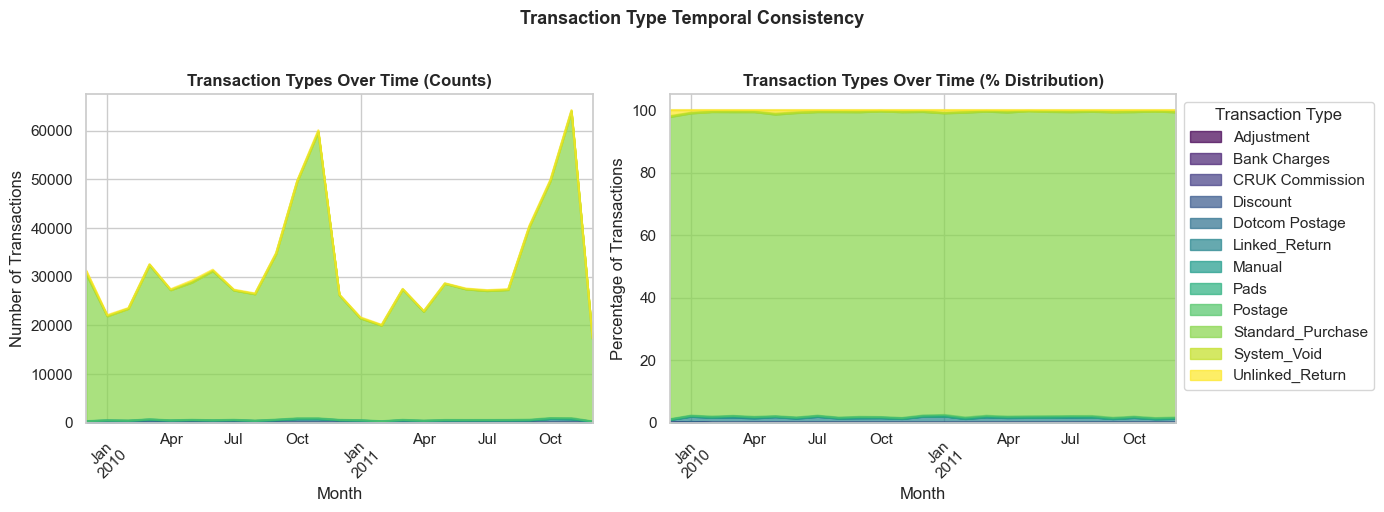

In [16]:
transaction_type_df = retail_df.copy()
transaction_type_df['YearMonth'] = (
    transaction_type_df['InvoiceDate'].dt.to_period('M')
)
monthly_txn_types = (
    transaction_type_df
    .groupby(['YearMonth', 'TransactionType'], observed=False)
    .size()
    .unstack(fill_value=0)
)
monthly_txn_types_pct = (
    monthly_txn_types
    .div(monthly_txn_types.sum(axis=1), axis=0) * 100
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

monthly_txn_types.plot(
    kind='area', stacked=True, ax=axes[0],
    colormap='viridis', alpha=0.7, legend=False
)
axes[0].set_title('Transaction Types Over Time (Counts)',
                  fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Number of Transactions')
axes[0].tick_params(axis='x', rotation=45)

monthly_txn_types_pct.plot(
    kind='area', stacked=True, ax=axes[1],
    colormap='viridis', alpha=0.7
)
axes[1].set_title('Transaction Types Over Time (% Distribution)',
                  fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Percentage of Transactions')
axes[1].legend(title='Transaction Type',
               bbox_to_anchor=(1, 1), loc='upper left')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Transaction Type Temporal Consistency',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("../reports/figures/transaction_types_over_time.png",
            bbox_inches="tight", dpi=150)
plt.show()

The absolute and relative views together confirm temporal 
consistency. Standard purchases dominate throughout and 
relative composition is stable even during Q4 peaks.

The non-standard transaction types are examined separately 
below to confirm their individual patterns are also consistent 
over time.

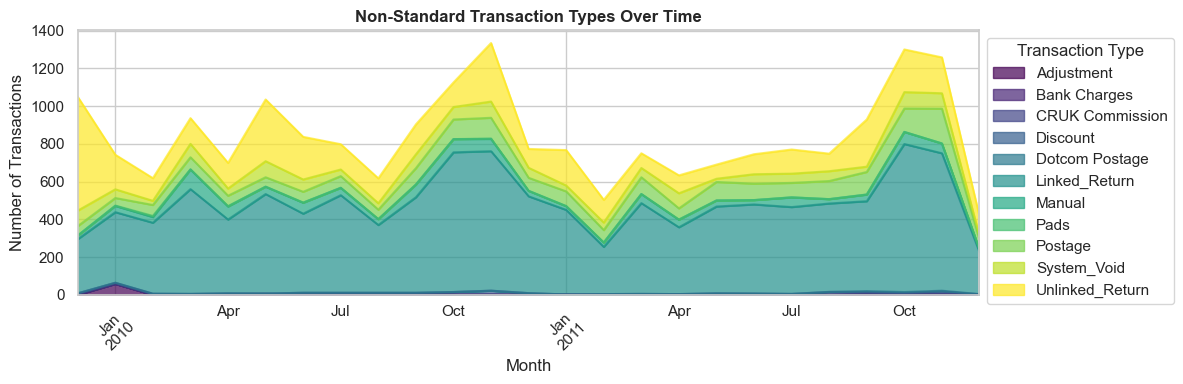

In [17]:
non_standard = monthly_txn_types.drop(columns=['Standard_Purchase'])

non_standard.plot(
    kind='area',
    stacked=True,
    colormap='viridis',
    alpha=0.7,
    figsize=(12, 4)
)
plt.title('Non-Standard Transaction Types Over Time',
          fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.legend(title='Transaction Type',
           bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.savefig("../reports/figures/non_standard_transactions_over_time.png",
            bbox_inches="tight", dpi=150)
plt.show()

Both charts confirm the labeling logic is temporally stable. 
Transaction volumes show a strong Q4 seasonal spike across all 
types. Non-Q4 periods show consistent baseline 
volumes with no unexplained drift or structural breaks.

The relative composition chart confirms the proportion of 
each transaction type remains stable even during peak periods.
The labeling logic does not produce disproportionately more 
or fewer returns during high-volume months, which would suggest 
a matching bias.

This stability validates the labeling logic for downstream 
feature engineering.

## 6. Outlier Assessment

Before finalizing the dataset, extreme values in `Price` and 
`Quantity` are examined by transaction type. The goal is not 
to remove outliers but to confirm they represent legitimate 
business behavior rather than data errors.

Tree-based models used in the modeling stage are robust to 
extreme values in continuous features, so outliers are retained 
unless they are clearly erroneous

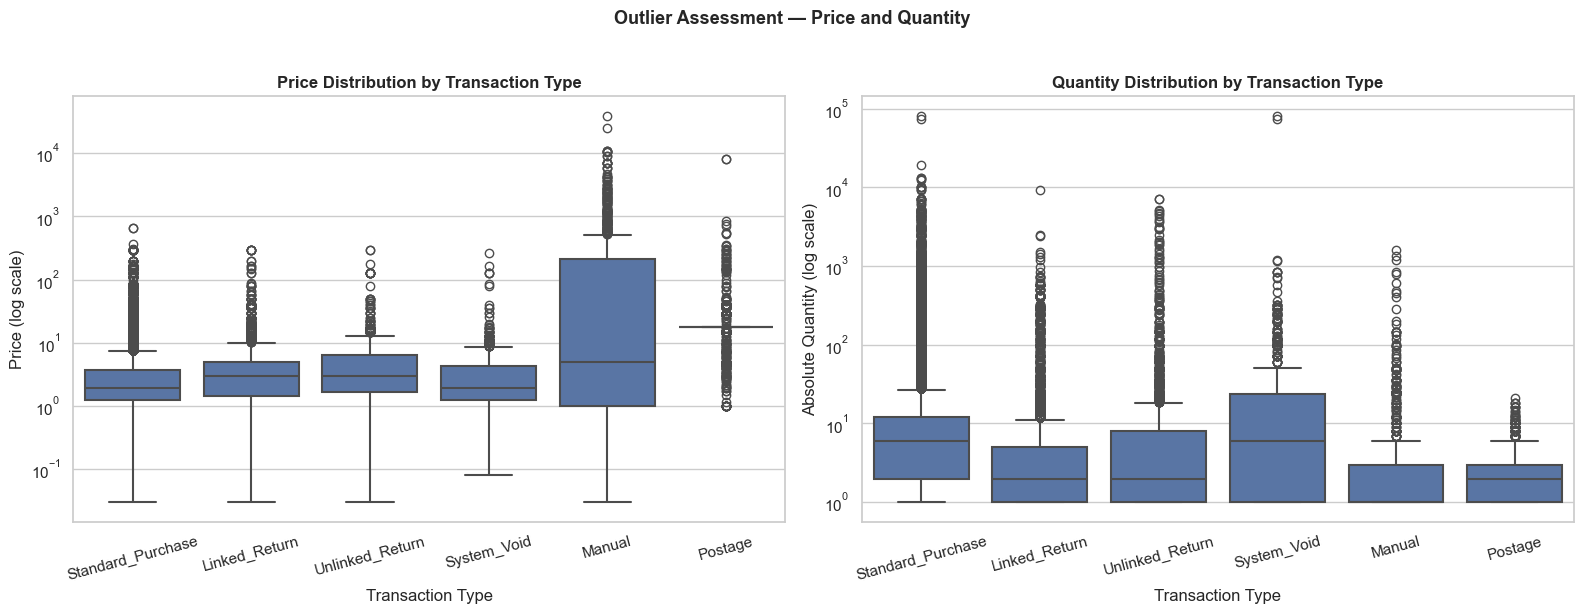

In [18]:
order = [
    "Standard_Purchase",
    "Linked_Return",
    "Unlinked_Return",
    "System_Void",
    "Manual",
    "Postage",
]

plot_df = retail_df.copy()
plot_df['AbsQuantity'] = plot_df['Quantity'].abs()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(
    data=retail_df,
    x="TransactionType",
    y="Price",
    order=order,
    linewidth=1.5,
    ax=axes[0],
)
axes[0].set_yscale("log")
axes[0].set_title("Price Distribution by Transaction Type",
                  fontweight='bold')
axes[0].set_xlabel("Transaction Type")
axes[0].set_ylabel("Price (log scale)")
axes[0].tick_params(axis='x', rotation=15)

sns.boxplot(
    data=plot_df,
    x="TransactionType",
    y="AbsQuantity",
    order=order,
    linewidth=1.5,
    ax=axes[1],
)
axes[1].set_yscale("log")
axes[1].set_title("Quantity Distribution by Transaction Type",
                  fontweight='bold')
axes[1].set_xlabel("Transaction Type")
axes[1].set_ylabel("Absolute Quantity (log scale)")
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle("Outlier Assessment — Price and Quantity",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("../reports/figures/outlier_assessment.png",
            bbox_inches="tight", dpi=150)
plt.show()

Both `Price` and `Quantity` show heavy right tails across 
transaction types. Quantity is plotted as absolute values 
to allow all transaction types (including returns with 
negative quantities) to appear on a log scale.

**Price** distributions are consistent across Standard 
Purchases, Returns, and System Voids (all centered around 
£3–5 with similar spreads). This confirms that returns and 
voids are matched to realistically priced products rather 
than arbitrary values. Postage charges show a narrow 
distribution around £2–3, consistent with fixed-rate 
postage fees.

Manual transactions stand out clearly. An IQR spanning 
roughly £1 to £200 with extreme outliers reaching £10,000+, 
far wider than any other transaction type. This confirms 
Manual entries represent irregular administrative adjustments 
rather than standard product transactions and should be 
excluded from customer behavioral metrics.

**Quantity** tells a complementary story. Standard 
Purchases have the widest spread with extreme outliers 
exceeding 80,000 units (consistent with bulk B2B 
wholesale orders). Linked Returns show smaller quantities 
than their purchase counterparts, suggesting customers 
typically return partial rather than full orders. 
Unlinked Returns show a similar central distribution 
to Linked Returns but with more extreme outliers, 
which may reflect large partial returns without a 
traceable original purchase.

System Voids show quantity distributions similar to 
Standard Purchases. As expected, they represent 
corrections to real orders. Postage and Manual entries 
show very small quantities near 1, consistent with 
their administrative nature.

All outliers are retained. Extreme values in Price and 
Quantity reflect legitimate customer segments
(particularly bulk B2B buyers) and the tree-based 
models used in the modeling stage are robust to such 
values.

## 7. Data Validation

Integrity checks confirm all cleaning and labeling rules were 
applied correctly before the dataset is exported. Each assertion 
tests a specific invariant that must hold for the downstream 
notebooks to produce valid results.

In [19]:
assert retail_df['CustomerID'].isnull().sum() == 0, \
    "Missing CustomerIDs found."

assert retail_df['Description'].isnull().sum() == 0, \
    "Missing Descriptions found."

assert (retail_df['Price'] > 0).all(), \
    "Non-positive prices detected."

internal_adjustments_remaining = retail_df[
    (retail_df['Price'] == 0) & (retail_df['Quantity'] < 0)
]
assert len(internal_adjustments_remaining) == 0, \
    f"Found {len(internal_adjustments_remaining)} internal adjustment records still present."

unlabeled_negatives = retail_df[
    (retail_df['Quantity'] < 0) &
    (retail_df['TransactionType'] == 'Standard_Purchase')
]

assert len(unlabeled_negatives) == 0, \
    f"{len(unlabeled_negatives)} negative transactions were not properly categorized."

# Type Checks
assert pd.api.types.is_datetime64_any_dtype(retail_df['InvoiceDate']), \
    "InvoiceDate is not datetime type."

assert retail_df['TransactionType'].dtype.name == 'category', \
    "Transaction_Type should be categorical."

print("All data integrity checks passed.")

All data integrity checks passed.


All checks passing confirms:

- No missing customer identifiers or descriptions remain
- All prices are strictly positive
- No internal adjustment records survived the cleaning step
- Every negative quantity transaction has been assigned a 
  non-standard transaction type label
- Data types are correct for downstream processing

## 8. Finalization

The cleaned and labeled dataset is prepared for export. 
`TotalSum` is computed as `Quantity × Price`. This will be 
negative for returns and voids, correctly reflecting their 
impact on revenue at the transaction level.

In [20]:
# Compute transaction-level total value
retail_df['TotalSum'] = retail_df['Quantity'] * retail_df['Price']

In [21]:
print("Final dataset summary")
print("-" * 45)
print(f"  Rows:              {len(retail_df):,}")
print(f"  Columns:           {retail_df.shape[1]}")
print(f"  Unique customers:  {retail_df['CustomerID'].nunique():,}")
print(f"  Unique products:   {retail_df['StockCode'].nunique():,}")
print(f"  Date range:        {retail_df['InvoiceDate'].min().date()} → "
      f"{retail_df['InvoiceDate'].max().date()}")
print()
print("Transaction type breakdown")
print("-" * 45)
type_counts = retail_df['TransactionType'].value_counts()
for tx_type, count in type_counts.items():
    pct = count / len(retail_df)
    print(f"  {str(tx_type):<22} {count:>8,}  ({pct:.1%})")
print()

# Save
output_path = '../data/processed/online_retail_cleaned.parquet'
retail_df.to_parquet(output_path, index=False)
print(f"  ✓ Saved to {output_path}")

Final dataset summary
---------------------------------------------
  Rows:              797,815
  Columns:           11
  Unique customers:  5,939
  Unique products:   4,646
  Date range:        2009-12-01 → 2011-12-09

Transaction type breakdown
---------------------------------------------
  Standard_Purchase       776,840  (97.4%)
  Linked_Return            11,906  (1.5%)
  Unlinked_Return           4,350  (0.5%)
  Postage                   1,983  (0.2%)
  System_Void               1,340  (0.2%)
  Manual                    1,078  (0.1%)
  Discount                    170  (0.0%)
  Adjustment                   61  (0.0%)
  Bank Charges                 37  (0.0%)
  Pads                         18  (0.0%)
  CRUK Commission              16  (0.0%)
  Dotcom Postage               16  (0.0%)

  ✓ Saved to ../data/processed/online_retail_cleaned.parquet
